Problem 1: Reproduce the ballistics example in chapter 6.5.1.

We have a simple model of a projectile being launched vertically, its elevation at time t is:

$y=m_1+m_2t+m_3t^2$

where $m_1$ is initial height, $m_2$ is initial velocity and $m_3$ is gravitational acceleration. The parameter vector is given:

$\begin{bmatrix} m_1 & m_2 & m_3 \end{bmatrix}^\mathsf{T}$


And the actual parameters are:

$\begin{bmatrix} 10  & 100 & 9.8 \end{bmatrix}^\mathsf{T}$


Samples are drawn according to:

$d_i=y(t_i) + \epsilon_i$  

Where

$\epsilon \sim \mathcal{N}(0, \sigma^2)$

$\sigma=8$


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.special import softmax

# define model with which to draw samples from 

mu = 0
sigma = 8
interval = (1, 10)
num_samples = 10
param_actual = np.array([10, 100, 9.8])

def generate_ballistic_data(mu: float,
                            sigma: float,
                            interval: tuple[float, float],
                            num_samples: int,
                            coeffs,
                            noise: bool = True
                            ):
    time_steps = np.linspace(interval[0], interval[1], num=num_samples)
    data = coeffs[0] + coeffs[1]*time_steps - (0.5)*coeffs[2]*(time_steps**2)
    if noise:
        data = data + np.random.normal(0, sigma, len(data))
    return data, time_steps

def build_design_matrix(time_steps):
    design_matrix = np.zeros((len(time_steps), 3))
    for i in range(3):
        design_matrix[:, i] = time_steps**i
    design_matrix[:, 2] *= -0.5
    return design_matrix

# random samples generated above
test_samples, time_steps = generate_ballistic_data(mu, sigma, interval, num_samples, param_actual, noise=True)   

# samples from the notes for verification
note_samples = np.array([109.4, 187.5, 267.5, 331.9, 386.1, 428.4, 452.2, 498.1, 512.3, 513.0])


Our Model is:

$\mathbf{d} = G\mathbf{m} + \epsilon$

$\epsilon \sim \mathcal{N}(\mathbf{0}, \sigma^2 \mathbf{I})$

The likelihood is given:

$p(\mathbf{d}|\mathbf{m}) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi \sigma^2}} e^{-\frac{(d_i - G_i \mathbf{m})^2}{2\sigma^2}}$

Taking the log of both sides gives:

$ln(p(\mathbf{d}|\mathbf{m})) = \Sigma_{i=1}^{n} ln(\frac{1}{\sqrt{2\pi \sigma^2}} e^{-\frac{(d_i - G_i m_i)^2}{2\sigma^2}})$

$=\Sigma_{i=1}^{n}(ln(\frac{1}{\sqrt{2\pi \sigma^2}}) + ln(e^{-\frac{(d_i - G_i m_i)^2}{2\sigma^2}}))$

$=\Sigma_{i=1}^{n}ln(\frac{1}{\sqrt{2\pi \sigma^2}}) - \Sigma_{i=1}^{n} \frac{(d_i - G_i m_i)^2}{2\sigma^2}$

$= -\frac{n}{2}ln(2\pi \sigma^2) - \frac{1}{2\sigma^2} \lVert \mathbf{d} - G\mathbf{m} \rVert^2$

Which is our log-likelihood since $-\frac{n}{2}ln(2\pi \sigma^2)$ is constant in $\mathbf{m}$ if we want to maximize this equation we
must minimize the term on the right which is equivalent to minimizing the sum of squared residuals which means our solution is given by 
the normal equations:

$\hat{\mathbf{m}} = (G^{\top}G)^{-1}G^{\top} \mathbf{d}$


In [25]:
# to minimize the least square residual we solve the normal equation
g_mat = build_design_matrix(time_steps)
first_term = g_mat.T @ g_mat
inv = np.linalg.inv(first_term)
last_mat = inv @ g_mat.T

# solution
m_hat = last_mat @ note_samples
print(m_hat)

[16.40833333 96.97128788  9.40833333]


In [26]:
# plot observations, true and predicted ballistics
predicted, time_steps = generate_ballistic_data(mu, sigma, interval, num_samples, m_hat, noise=False)
actual, _ = generate_ballistic_data(mu, sigma, interval, num_samples, param_actual, noise=False)

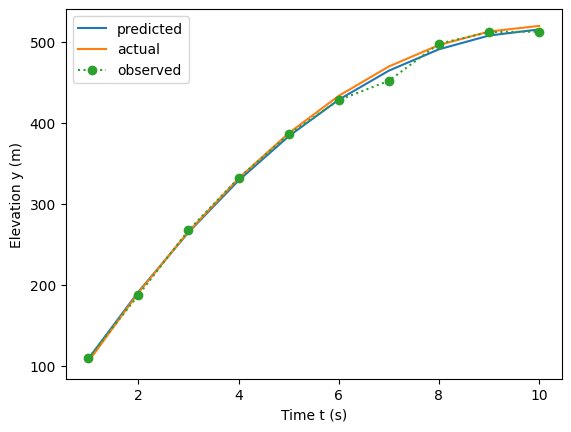

In [27]:
plt.plot(time_steps, predicted, label='predicted')
plt.plot(time_steps, actual, label='actual')
plt.plot(time_steps, note_samples, label='observed', linestyle='dotted', marker='o')
plt.legend()
plt.xlabel('Time t (s)')
plt.ylabel('Elevation y (m)')
plt.show()

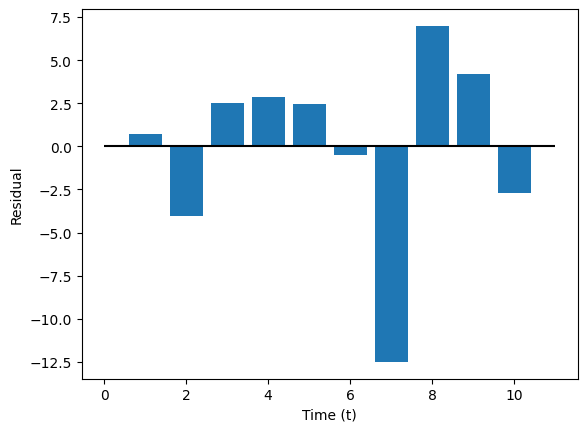

In [28]:
# plot the residuals
plt.clf()
residuals = note_samples - predicted
plt.bar(time_steps, residuals)
plt.hlines(y=0, xmin=0, xmax=11, color='black')
plt.xlabel('Time (t)')
plt.ylabel('Residual')
plt.show()

Problem 2

In [49]:
def joint_pdf(x, y, sig_q, x_0, sig_x):
    first_term = -0.5*(((y - np.cos(x))/sig_q)**2)
    second_term = -0.5*(((x-x_0)/sig_x)**2)
    pdf_raw = np.exp(first_term + second_term)
    return pdf_raw

# define grid
x_range = (-4, 4)
y_range = (-4, 4)
num_cells = 1000

# define params
sig_x = 0.5
sig_q = 1
sig_y = 0.3
d = -0.5
x_0 = 1

x = np.linspace(x_range[0], x_range[1], num_cells)
y = np.linspace(y_range[0], y_range[1], num_cells)
xx, yy = np.meshgrid(x, y)
unormalized_logits = joint_pdf(xx, yy, sig_q, x_0, sig_x)
normalizer = unormalized_logits.sum()
normalized_logits = unormalized_logits/normalizer
prior_x = norm.pdf(x, x_0, sig_x) - 4
green = 100*np.sum(normalized_logits, axis=1) - 4
normalized_logits.sum()

np.float64(1.0)

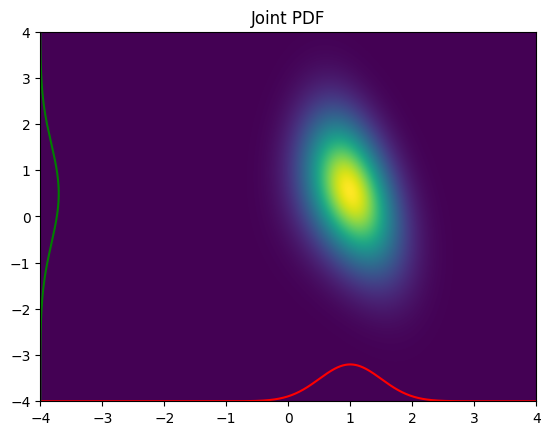

In [51]:
fig, ax = plt.subplots()
im = ax.imshow(normalized_logits, extent = [x.min(), x.max(), y.min(), y.max()],
               origin='lower', cmap='viridis', aspect='auto')
plt.plot(x, prior_x, color='red')
plt.plot(green, y, color='green') 
ax.set_title('Joint PDF')
plt.show()

In [100]:
def conditional_pdf(x, y, sig_q, x_0, sig_x, d, sig_y):
    first_term = -0.5*(((y - np.cos(x))/sig_q)**2)
    second_term = -0.5*(((x-x_0)/sig_x)**2)
    third_term = -0.5*(((d-y)/sig_y)**2)
    unnormalized_logits = np.exp(first_term + second_term + third_term)
    return unnormalized_logits

unnormalized_logits_conditional = conditional_pdf(xx, yy, sig_q, x_0, sig_x, d, sig_y)
norm = unnormalized_logits_conditional.sum()
prob = unnormalized_logits_conditional/norm
yellow = 100*np.sum(unnormalized_logits_conditional, axis=0)/np.sum(yellow)

<Figure size 640x480 with 0 Axes>

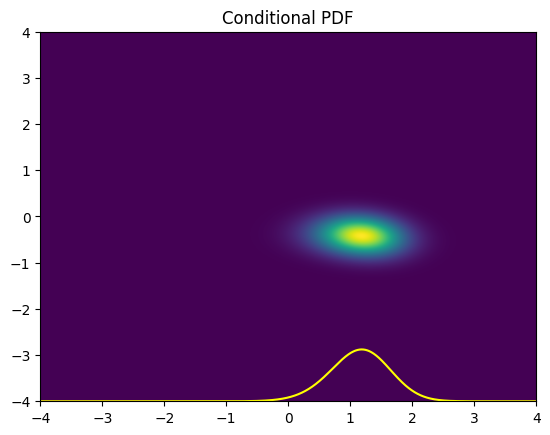

In [102]:
plt.clf()
fig, ax = plt.subplots()
im = ax.imshow(unnormalized_logits_conditional, extent = [x.min(), x.max(), y.min(), y.max()],
               origin='lower', cmap='viridis', aspect='auto')
ax.set_title('Conditional PDF')
plt.plot(x, -yellow-4, color='yellow')
plt.show()